# 02 — Processing time model


The twin simulates the LITHOGRAPHY workshop. To behave like the real workshop, it needs three ingredients, all learned from the data:

1. **How long does a processing take?** One Gamma distribution per recipe (this notebook)
2. **When do machines break down, and for how long?** Machine breakdowns (`03_machine_breakdowns`)
3. **When a machine becomes free, which lot does it pick?** Dispatching rule (`04_dispatching_rule`)

Loads the prepared data from the `wafer_twin` package.

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

In [1]:
from wafer_twin.data import load_tables, build_process

tables = load_tables()
process = build_process(tables)

# sanity check
print(process.shape)
print("negative waits:", (process["WAIT_MIN"] < 0).sum())
process.groupby("WORKSHOP")["WAIT_MIN"].mean().round(2)

(1755296, 12)
negative waits: 0


WORKSHOP
ETCHING            71.08
IMPLEMENTATION     14.89
LITHOGRAPHY       155.72
Name: WAIT_MIN, dtype: float64

## Lithography processing times

The twin has to draw a random processing time each time a machine starts a lot.

First, we look at the observed durations before choosing a distribution.

In [5]:
# summary of durations
litho = process[process["WORKSHOP"] == "LITHOGRAPHY"].copy()

print(f"{len(litho):,} operations")
litho["PROCESS_TIME_MIN"].describe()

614,186 operations


count    614186.000000
mean         67.982590
std          47.559600
min           0.001667
25%          39.409479
50%          58.702425
75%          82.977075
max        1101.492800
Name: PROCESS_TIME_MIN, dtype: float64

In [6]:
# how many suspiciously short operations
for threshold in [0.1, 1, 5, 10]:
    n = (litho["PROCESS_TIME_MIN"] < threshold).sum()
    print(f"< {threshold:>4} min: {n:>7,} ops ({n / len(litho):.2%})")

<  0.1 min:      90 ops (0.01%)
<    1 min:     706 ops (0.11%)
<    5 min:   4,710 ops (0.77%)
<   10 min:  11,888 ops (1.94%)


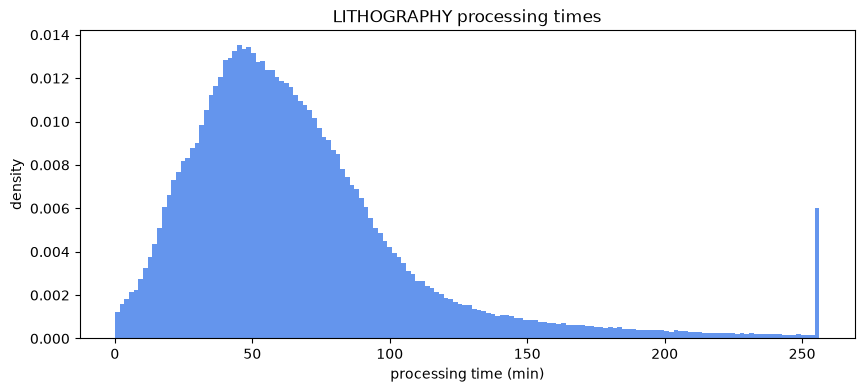

In [7]:
upper = litho["PROCESS_TIME_MIN"].quantile(0.99)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(litho["PROCESS_TIME_MIN"].clip(upper=upper), bins=150, density=True, color="#6495ED")
ax.set_xlabel("processing time (min)")
ax.set_ylabel("density")
ax.set_title("LITHOGRAPHY processing times")
plt.show()

### Takeaways :

- Right-skewed hump: most operations take 40–80 min, peak around 45–50 min, long right tail (max ~18 h)
- Mean (68 min) > median (59 min) because of the tail
- Very short operations are rare (0.11% under 1 min) and the left side rises smoothly from 0:
  no separate cluster of recording errors, so they are kept
- The spike at ~256 min is a plotting artefact (values clipped at the 99th percentile)

## Choosing a distribution

Two candidates, both fitted by maximum likelihood with location fixed at 0:

- **Exponential**: 1 parameter (the mean), mode always at 0
- **Gamma**: shape *k* and scale *θ*, mean = *k·θ*; has a hump when *k* > 1

Compared visually and with AIC (lower is better).

In [ ]:
# adjust the two laws

x = litho["PROCESS_TIME_MIN"].to_numpy()

# loc fixed at 0, a duration starts at 0
k, _, theta = stats.gamma.fit(x, floc=0)
_, mean_exp = stats.expon.fit(x, floc=0)

print(f"gamma:       k = {k:.3f}, theta = {theta:.2f} min, mean = {k * theta:.2f} min")
print(f"exponential: mean = {mean_exp:.2f} min")

gamma:       k = 2.538, theta = 26.78 min, mean = 67.98 min
exponential: mean = 67.98 min


In [13]:
# compare to AIC
ll_gamma = stats.gamma.logpdf(x, k, scale=theta).sum()
ll_exp = stats.expon.logpdf(x, scale=mean_exp).sum()

# AIC = 2 * nb params - 2 * log-likelihood
aic = pd.Series({
    "exponential": 2 * 1 - 2 * ll_exp,
    "gamma": 2 * 2 - 2 * ll_gamma,
})
aic.round(0)

exponential    6411185.0
gamma          6175927.0
dtype: float64

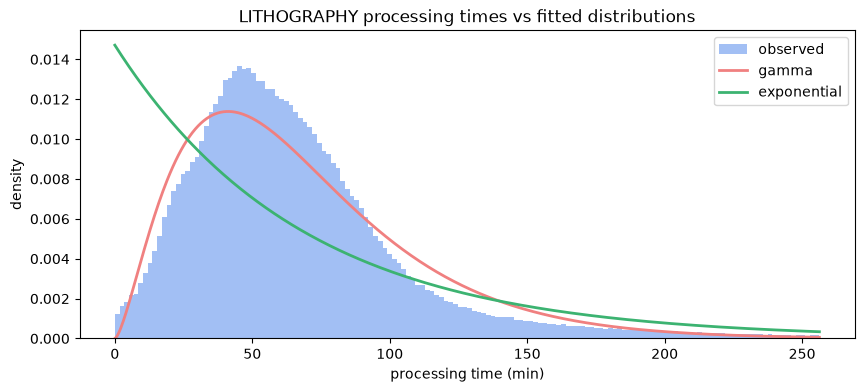

In [14]:
upper = np.quantile(x, 0.99)
grid = np.linspace(0, upper, 500)

fig, ax = plt.subplots(figsize=(10, 4))
# range instead of clip, no more fake spike at the end
ax.hist(x, bins=150, range=(0, upper), density=True, color="#6495ED", alpha=0.6, label="observed")
ax.plot(grid, stats.gamma.pdf(grid, k, scale=theta), color="#F08080", lw=2, label="gamma")
ax.plot(grid, stats.expon.pdf(grid, scale=mean_exp), color="#3CB371", lw=2, label="exponential")
ax.set_xlabel("processing time (min)")
ax.set_ylabel("density")
ax.set_title("LITHOGRAPHY processing times vs fitted distributions")
ax.legend()
plt.show()

### Takeaways :

- Exponential is clearly wrong: its mode is at 0, the data has a hump around 45–50 min
- Gamma fits much better: k = 2.54, θ = 26.8 min, AIC lower by ~235,000
- Both fits share the sample mean (67.98 min), a property of maximum likelihood for these two laws
- Gamma is still too wide and its peak too low: all recipes are pooled,
  and mixing recipes with different typical durations widens the distribution

## Effect of the recipe

If recipes have different typical durations, pooling them widens the distribution.

Check: spread of recipe means, and coefficient of variation (CV = std / mean) within each recipe
compared with the pooled CV (~0.70).

In [15]:
by_recipe = litho.groupby("RECIPE")["PROCESS_TIME_MIN"].agg(["count", "mean", "median", "std"])
by_recipe["cv"] = by_recipe["std"] / by_recipe["mean"]

print(len(by_recipe), "recipes in LITHOGRAPHY")
by_recipe.sort_values("count", ascending=False).head(10).round(2)

28 recipes in LITHOGRAPHY


,count,mean,median,std,cv
RECIPE,,,,,
RECIPE_0027,45840,76.55,75.37,15.22,0.20
RECIPE_0016,45224,58.42,56.08,20.96,0.36
RECIPE_0021,45220,78.13,73.80,32.25,0.41
RECIPE_0023,44008,71.56,69.62,20.92,0.29
RECIPE_0026,34195,31.90,29.92,13.14,0.41
RECIPE_0012,33745,81.37,79.19,23.58,0.29
RECIPE_0018,31358,41.77,38.30,23.34,0.56
RECIPE_0029,27797,49.97,47.14,21.99,0.44
RECIPE_0003,27772,109.45,98.72,61.61,0.56


In [16]:
# how different are the recipes from each other
print(by_recipe[["count", "mean", "cv"]].describe().round(2))

# CV inside recipes, weighted by how often each recipe is used
weighted_cv = np.average(by_recipe["cv"], weights=by_recipe["count"])
print(f"\npooled CV: {x.std() / x.mean():.2f}")
print(f"mean CV inside recipes (weighted): {weighted_cv:.2f}")

          count    mean     cv
count     28.00   28.00  28.00
mean   21935.21   69.01   0.51
std    13131.86   28.81   0.26
min     4227.00   22.63   0.18
25%    12038.25   46.30   0.29
50%    17754.00   69.57   0.43
75%    28687.25   85.19   0.65
max    45840.00  141.97   1.08

pooled CV: 0.70
mean CV inside recipes (weighted): 0.46


### Takeaways :

- 28 recipes, mean durations from 23 to 142 min
- Knowing the recipe cuts the dispersion by about a third (CV 0.70 → 0.46)
- Every recipe has at least 4,227 operations: enough to fit one distribution per recipe
- Within-recipe CV ranges from 0.18 to 1.08, so the Gamma shape differs a lot between recipes
  (CV = 1/√k): a model with a common shape across recipes (Gamma GLM) does not fit this data
- Decision: one Gamma distribution per recipe, each with its own k and θ

## One Gamma per recipe

Fit k and θ separately for each recipe, then compare with the single pooled Gamma:
- AIC (56 parameters vs 2)
- the mixture of the 28 recipe Gammas, weighted by recipe frequency, against the observed histogram

In [18]:
# adjust the 28 laws
fits = {}
for recipe, g in litho.groupby("RECIPE"):
    xr = g["PROCESS_TIME_MIN"].to_numpy()
    k_r, _, theta_r = stats.gamma.fit(xr, floc=0)
    fits[recipe] = {
        "n": len(xr),
        "k": k_r,
        "theta": theta_r,
        "mean": k_r * theta_r,
        "loglik": stats.gamma.logpdf(xr, k_r, scale=theta_r).sum(),
    }

gamma_by_recipe = pd.DataFrame.from_dict(fits, orient="index")
gamma_by_recipe.sort_values("k").round(2)

,n,k,theta,mean,loglik
RECIPE_0009,6356,0.96,88.47,85.25,-34609.08
RECIPE_0002,27736,1.17,83.29,97.08,-154447.76
RECIPE_0015,25565,1.24,54.58,67.59,-132938.96
RECIPE_0013,7979,1.31,71.43,93.51,-44022.38
RECIPE_0024,16136,1.57,32.86,51.48,-78866.33
RECIPE_0020,12077,1.61,52.92,85.17,-65035.56
RECIPE_0030,11922,2.00,56.40,112.88,-66884.78
RECIPE_0025,12128,2.62,8.65,22.63,-47512.82
RECIPE_0005,27753,2.62,40.99,107.51,-151941.60
RECIPE_0018,31358,2.98,14.03,41.77,-140604.29


In [19]:
# compare to AIC
n_params = 2 * len(gamma_by_recipe)
aic_by_recipe = 2 * n_params - 2 * gamma_by_recipe["loglik"].sum()

print(f"single gamma (2 params):        AIC = {aic['gamma']:,.0f}")
print(f"gamma per recipe ({n_params} params): AIC = {aic_by_recipe:,.0f}")
print(f"difference: {aic['gamma'] - aic_by_recipe:,.0f}")

single gamma (2 params):        AIC = 6,175,927
gamma per recipe (56 params): AIC = 5,631,383
difference: 544,544


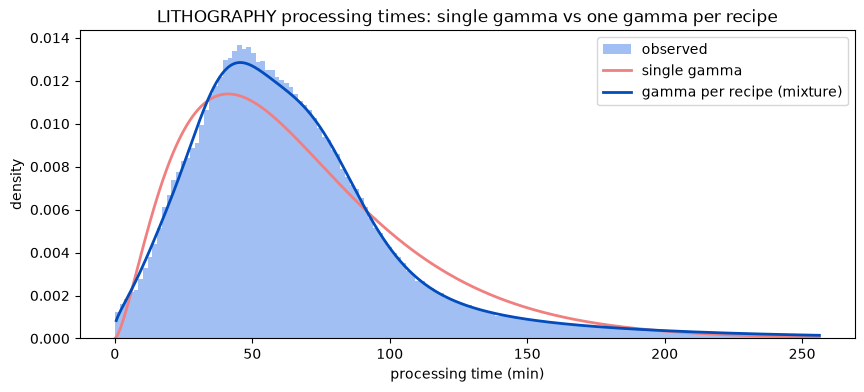

In [23]:
weights = gamma_by_recipe["n"] / gamma_by_recipe["n"].sum()

# sum of the recipe densities, each weighted by how often the recipe is used
mixture = sum(
    w * stats.gamma.pdf(grid, r.k, scale=r.theta)
    for w, r in zip(weights, gamma_by_recipe.itertuples())
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(x, bins=150, range=(0, upper), density=True, color="#6495ED", alpha=0.6, label="observed")
ax.plot(grid, stats.gamma.pdf(grid, k, scale=theta), color="#F08080", lw=2, label="single gamma")
ax.plot(grid, mixture, color="#024CBB", lw=2, label="gamma per recipe (mixture)")
ax.set_xlabel("processing time (min)")
ax.set_ylabel("density")
ax.set_title("LITHOGRAPHY processing times: single gamma vs one gamma per recipe")
ax.legend()
plt.show()

### Takeaways :

- The mixture of the 28 recipe Gammas reproduces the pooled histogram almost exactly
  (peak height, position, shoulder around 70–80 min, tail)
- AIC drops by ~545,000 despite 54 extra parameters: the gain is real
- Shapes vary widely: k from 0.96 (RECIPE_0009, no hump, exponential-like)
  to 31.9 (RECIPE_0028, very regular)
- Irregular recipes (low k) also tend to be slow (mean 85–97 min)

In [24]:
# quantile verification

rows = []
for recipe, g in litho.groupby("RECIPE"):
    p = gamma_by_recipe.loc[recipe]
    for q in [0.5, 0.9, 0.99]:
        obs = g["PROCESS_TIME_MIN"].quantile(q)
        fit = stats.gamma.ppf(q, p["k"], scale=p["theta"])
        rows.append({"RECIPE": recipe, "q": q, "rel_err": (fit - obs) / obs})

# relative error, > 0 means the gamma overestimates
qcheck = pd.DataFrame(rows).pivot(index="RECIPE", columns="q", values="rel_err")

print(qcheck.abs().describe().round(3))
qcheck.sort_values(0.99).round(3)

q        0.50    0.90    0.99
count  28.000  28.000  28.000
mean    0.018   0.010   0.036
std     0.029   0.019   0.053
min     0.000   0.000   0.001
25%     0.003   0.002   0.005
50%     0.007   0.005   0.016
75%     0.021   0.010   0.039
max     0.142   0.104   0.242


q,0.50,0.90,0.99
RECIPE,,,
RECIPE_0030,0.019,-0.007,-0.061
RECIPE_0009,0.073,-0.004,-0.048
RECIPE_0013,0.051,-0.021,-0.043
RECIPE_0002,0.023,-0.005,-0.035
RECIPE_0015,0.021,0.014,-0.025
RECIPE_0011,0.022,-0.008,-0.017
RECIPE_0010,0.007,0.001,-0.016
RECIPE_0020,0.014,-0.009,-0.014
RECIPE_0005,0.004,-0.002,-0.005


### Takeaways :

- Per-recipe Gammas match observed quantiles closely: median absolute error
  0.7% (q50), 0.5% (q90), 1.6% (q99)
- Known limitation: RECIPE_0025 (q50 −14%, q99 +24%) and RECIPE_0026 (q99 +18%),
  the two fastest recipes (~7% of lithography operations). The Gamma overestimates their long
  durations, so the twin is slightly pessimistic there
- Irregular recipes (0030, 0009, 0013) have a slightly heavier tail than their Gamma (q99 −4 to −6%)
- Decision: keep one Gamma per recipe; an empirical distribution is the fallback
  if validation shows a problem

## Save the parameters

The simulation reads the per-recipe Gamma parameters from `params/`,
so it doesn't have to refit on the raw data at each run.

In [25]:
from wafer_twin.params import PARAMS_DIR, fit_gamma_by_recipe

litho_gamma = fit_gamma_by_recipe(process, "LITHOGRAPHY")

# same numbers as the notebook fit
check = (litho_gamma["k"] - gamma_by_recipe["k"]).abs().max()
print("max k difference vs notebook:", check)

PARAMS_DIR.mkdir(exist_ok=True)
litho_gamma.to_csv(PARAMS_DIR / "litho_processing_time_gamma.csv")
litho_gamma.round(3).head()

max k difference vs notebook: 0.0


,n,k,theta_min
RECIPE,,,
RECIPE_0001,27762,19.433,2.736
RECIPE_0002,27736,1.166,83.290
RECIPE_0003,27772,3.114,35.149
RECIPE_0004,14252,15.795,2.944
RECIPE_0005,27753,2.623,40.988
